# Spatial Data Analysis Demo

This notebook demonstrates the **core concepts** of spatial data analysis that students need to master:

## Learning Objectives
1. **Loading different data formats** (CSV with WKT geometry)
2. **Spatial joins** - transforming data between different geometries
3. **Data aggregation** across spatial boundaries
4. **Statistical analysis** on merged spatial datasets
5. **Configuration management** for flexible data processing

## The Challenge
We have rental price data by **zip code** but want to analyze it by **community area**. 
This requires:
- Loading data from different sources
- Converting WKT strings to geometries
- Performing spatial joins
- Aggregating data properly
- Analyzing the merged dataset

## Data Sources
- **Rental Data**: CSV with zip codes and rental prices
- **Zip Boundaries**: CSV with WKT polygon strings
- **Community Boundaries**: CSV with WKT polygon strings

## Configuration System
The pipeline uses a flexible configuration system that allows:
- Customizable data paths
- Configurable analysis parameters
- Environment variable support
- YAML/JSON configuration files


In [1]:
# Import the pipeline system
from pipeline import (
    CommunityBoundariesLoader,
    CorrelationAnalyzer,
    CorrelationVisualizer,
    Pipeline,
    RentalDataLoader,
    SpatialJoinProcessor,
    ZipBoundariesLoader,
    summary_reporter,
)
from pipeline.config import PipelineConfig

print("Pipeline system imported successfully!")
print("\nAvailable components:")
print("• RentalDataLoader - Load CSV rental data")
print("• ZipBoundariesLoader - Load CSV zip boundaries")
print("• CommunityBoundariesLoader - Load CSV community boundaries")
print("• SpatialJoinProcessor - Transform zip → community data")
print("• CorrelationAnalyzer - Analyze merged dataset")
print("• CorrelationVisualizer - Create visualizations")
print("• summary_reporter - Generate summary report")
print("\nConfiguration system:")
print("• PipelineConfig - Manage data paths and analysis parameters")

Pipeline system imported successfully!

Available components:
• RentalDataLoader - Load CSV rental data
• ZipBoundariesLoader - Load CSV zip boundaries
• CommunityBoundariesLoader - Load CSV community boundaries
• SpatialJoinProcessor - Transform zip → community data
• CorrelationAnalyzer - Analyze merged dataset
• CorrelationVisualizer - Create visualizations
• summary_reporter - Generate summary report

Configuration system:
• PipelineConfig - Manage data paths and analysis parameters


## Step 1: Create the Pipeline

We'll build a pipeline that demonstrates the complete workflow from raw data to analysis.


In [2]:
# Create the spatial analysis pipeline with configuration
config = PipelineConfig()
pipeline = Pipeline("Spatial Data Analysis Demo", config=config)
pipeline.load_config()

# Step 1: Load data from different sources (using config paths)
pipeline.register_component(RentalDataLoader())
pipeline.register_component(ZipBoundariesLoader())
pipeline.register_component(CommunityBoundariesLoader())

# Step 2: Perform spatial join (the hard part!)
pipeline.register_component(SpatialJoinProcessor())

# Step 3: Analyze the merged dataset
pipeline.register_component(CorrelationAnalyzer())
pipeline.register_component(CorrelationVisualizer())
pipeline.register_component(summary_reporter)

print("Pipeline created with 7 components")
print(f"Configuration loaded: {pipeline.pipeline_config is not None}")
print("\nPipeline workflow:")
for i, (_name, component) in enumerate(pipeline.components.items(), 1):
    print(f"{i}. {component.name} - {component.description}")

INFO:pipeline.config:Using default configuration with environment variables
INFO:pipeline.base:Loaded pipeline configuration
INFO:pipeline.base:Registered component: rental_data
INFO:pipeline.base:Registered component: zip_boundaries
INFO:pipeline.base:Registered component: community_boundaries
INFO:pipeline.base:Registered component: spatial_join
INFO:pipeline.base:Registered component: correlation_analysis
INFO:pipeline.base:Registered component: correlation_visualization
INFO:pipeline.base:Registered component: summary_reporter


Pipeline created with 7 components
Configuration loaded: True

Pipeline workflow:
1. rental_data - Load rental price data from ZORI dataset
2. zip_boundaries - Load zip code boundary data
3. community_boundaries - Load community area boundary data
4. spatial_join - Transform rental data from zip codes to community areas
5. correlation_analysis - Analyze correlations in community rental data
6. correlation_visualization - Create visualizations for correlation analysis
7. summary_reporter - Generate a summary report of the analysis


## Step 2: Execute the Pipeline

This will demonstrate the complete workflow, showing how data flows through each step.


INFO:pipeline.base:Starting pipeline execution: Spatial Data Analysis Demo
INFO:pipeline.base:Components to execute: ['rental_data', 'zip_boundaries', 'community_boundaries', 'spatial_join', 'correlation_analysis', 'correlation_visualization', 'summary_reporter']
INFO:pipeline.base:Executing component: rental_data
INFO:pipeline.components:Loading rental data from: /project/data/Zip_zori_uc_sfrcondomfr_sm_month.csv
INFO:pipeline.components:Loaded 8019 zip codes with rental data
INFO:pipeline.components:Rental price range: $528 - $93333
INFO:pipeline.base:Executing component: zip_boundaries
INFO:pipeline.components:Loading zip boundaries from: /project/data/Boundaries_ZIP_Codes.csv


Starting pipeline execution...


INFO:pipeline.components:Loaded 59 zip code boundaries
INFO:pipeline.components:CRS: EPSG:4326
INFO:pipeline.base:Executing component: community_boundaries
INFO:pipeline.components:Loading community boundaries from: /project/data/Boundaries_Community_Areas.csv
INFO:pipeline.components:Loaded 77 community area boundaries
INFO:pipeline.components:CRS: EPSG:4326
INFO:pipeline.base:Executing component: spatial_join
INFO:pipeline.components:Performing spatial join: zip codes -> community areas
INFO:pipeline.components:Step 1: Joining rental data with zip boundaries...
INFO:pipeline.components:Joined 54 zip codes with rental data
INFO:pipeline.components:Step 2: Performing spatial join (zip codes -> community areas)...
INFO:pipeline.components:Spatial join resulted in 262 zip-community pairs
INFO:pipeline.components:Step 3: Aggregating rental prices by community area...
INFO:pipeline.components:Final result: 77 community areas
INFO:pipeline.components:Areas with rental data: 76
INFO:pipeline

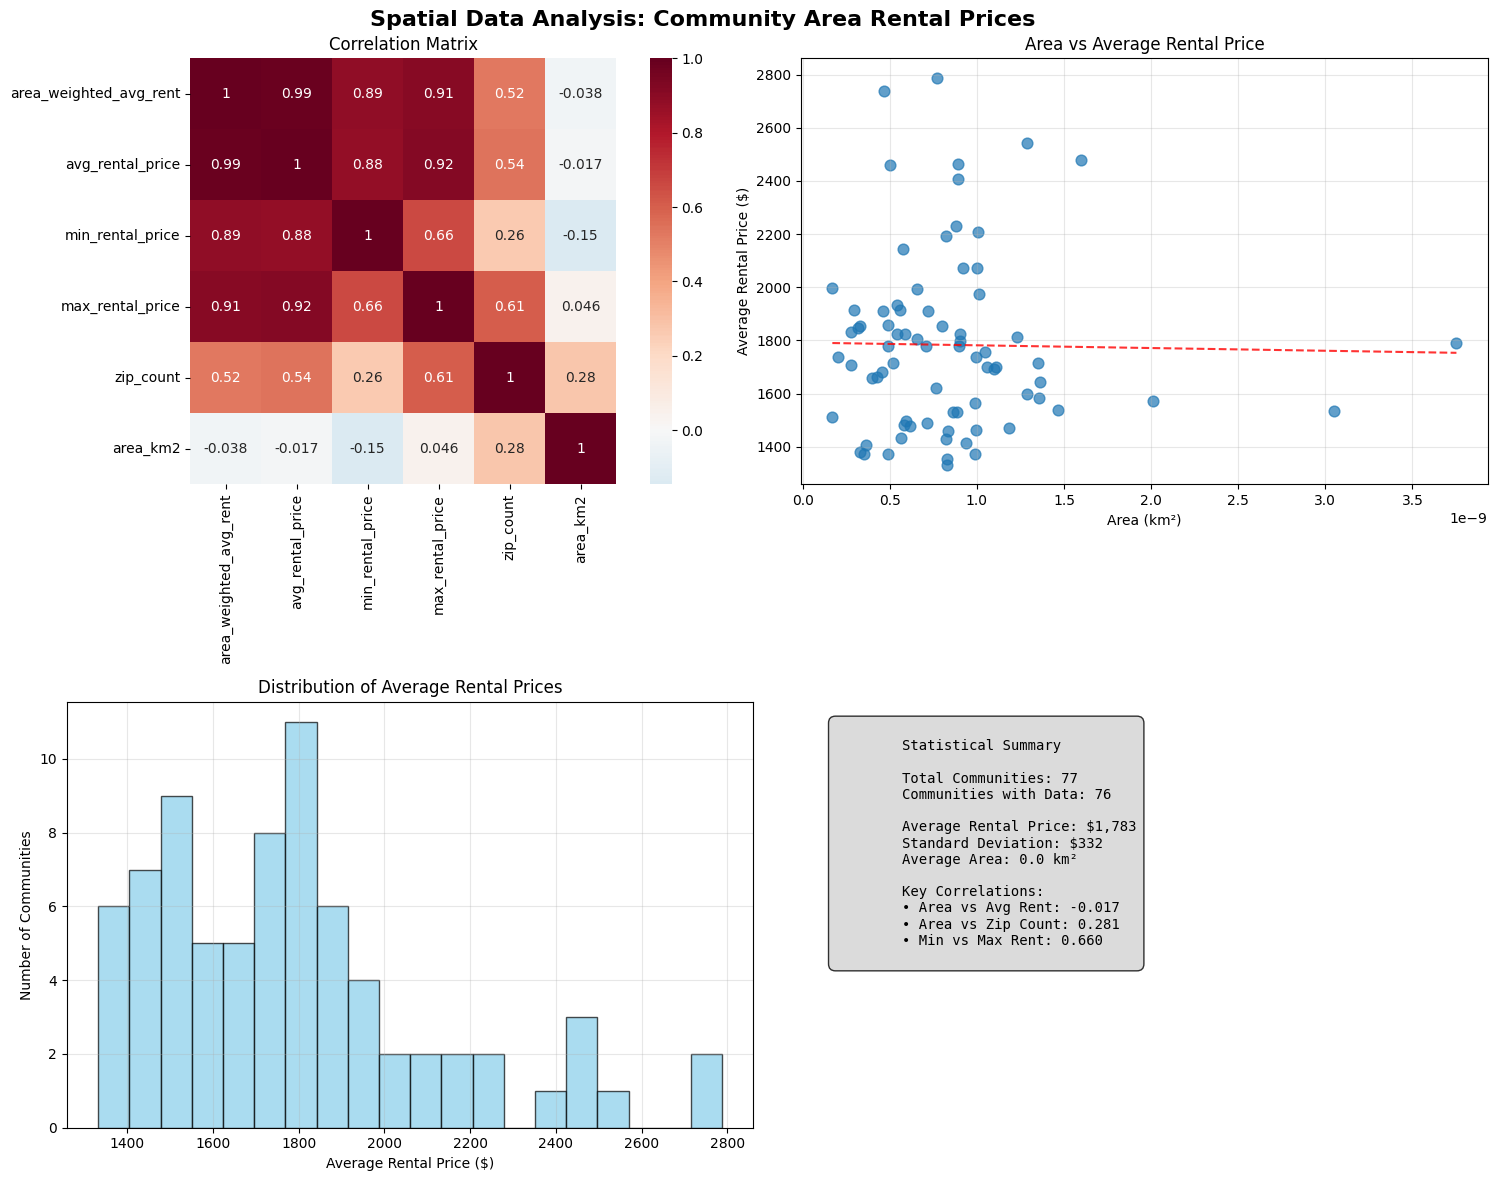

INFO:pipeline.base:Executing component: summary_reporter
INFO:pipeline.components:Generating summary report...
INFO:pipeline.base:Pipeline execution completed: Spatial Data Analysis Demo



SPATIAL DATA ANALYSIS SUMMARY REPORT

Dataset Overview:
  • Total Community Areas: 77
  • Areas with Rental Data: 76

Rental Price Statistics:
  • Average: $1,783
  • Standard Deviation: $332

Key Insights:
  • Area vs Average Rent: -0.017 (Weak)
  • Area vs Zip Count: 0.281 (Weak)
  • Min vs Max Rent: 0.660 (Moderate)
  • Average vs Area-Weighted Rent: 0.990 (Strong)

Pipeline execution completed!

Generated 7 results:
• rental_data: SUCCESS
• zip_boundaries: SUCCESS
• community_boundaries: SUCCESS
• spatial_join: SUCCESS
• correlation_analysis: SUCCESS
• correlation_visualization: SUCCESS
• summary_reporter: SUCCESS


In [3]:
# Execute the complete pipeline
print("Starting pipeline execution...")
print("=" * 60)

results = pipeline.execute()

print("\n" + "=" * 60)
print("Pipeline execution completed!")
print(f"\nGenerated {len(results)} results:")
for result in results:
    status = "SUCCESS" if result.success else "FAILED"
    print(f"• {result.component_name}: {status}")

## Step 3: Explore the Results

Let's examine what we've accomplished and the key insights from the analysis.


In [4]:
# Access the final results from the pipeline context
context = pipeline.context

print("ANALYSIS RESULTS")
print("=" * 40)

# Show the final merged dataset
if "community_rental_data" in context:
    final_data = context["community_rental_data"]
    print(f"\nFinal Dataset Shape: {final_data.shape}")
    print(f"Columns: {list(final_data.columns)}")

    # Show sample of the data
    print("\nSample of merged data:")
    display_cols = [
        "community_name",
        "avg_rental_price",
        "area_weighted_avg_rent",
        "zip_count",
    ]
    print(final_data[display_cols].head(10).to_string(index=False))

# Show correlation analysis results
if "summary_stats" in context:
    stats = context["summary_stats"]
    print("\nKEY INSIGHTS:")
    print(f"• Total communities analyzed: {stats.get('total_communities', 'N/A')}")
    print(
        f"• Communities with rental data: {stats.get('communities_with_data', 'N/A')}"
    )
    print(f"• Average rental price: ${stats.get('avg_rental_price', 0):,.0f}")

    print("\nKEY CORRELATIONS:")
    correlations = stats.get("key_correlations", {})
    # Define correlation strength thresholds
    STRONG_THRESHOLD = 0.7  # noqa: PLR2004
    MODERATE_THRESHOLD = 0.5  # noqa: PLR2004

    for name, corr in correlations.items():
        strength = (
            "Strong"
            if abs(corr) >= STRONG_THRESHOLD
            else "Moderate"
            if abs(corr) >= MODERATE_THRESHOLD
            else "Weak"
        )
        print(f"• {name}: {corr:.3f} ({strength})")

ANALYSIS RESULTS

Final Dataset Shape: (77, 15)
Columns: ['the_geom', 'AREA_NUMBE', 'community_name', 'AREA_NUM_1', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry', 'total_weighted_rent', 'total_area', 'avg_rental_price', 'min_rental_price', 'max_rental_price', 'zip_count', 'area_weighted_avg_rent', 'area_km2']

Sample of merged data:
 community_name  avg_rental_price  area_weighted_avg_rent  zip_count
    ROGERS PARK       1713.957374             1701.575369        3.0
     WEST RIDGE       1739.119572             1742.150615        5.0
         UPTOWN       1992.767491             1972.511766        2.0
 LINCOLN SQUARE       1912.043074             1926.675735        6.0
   NORTH CENTER       2144.952062             2139.506947        7.0
      LAKE VIEW       2232.348204             2266.965616        4.0
   LINCOLN PARK       2462.316112             2365.170004        6.0
NEAR NORTH SIDE       2788.369939             2742.903216        7.0
    EDISON PARK       1846.646825             1846.6

## Step 4: Understanding the Key Concepts

Let's examine the most challenging parts of this analysis in detail.


In [5]:
# Let's examine the spatial join process in detail
print("UNDERSTANDING THE SPATIAL JOIN PROCESS")
print("=" * 50)

# Show the data at each step
if "rental_data" in context:
    rental_data = context["rental_data"]
    print("\n1. RENTAL DATA (CSV):")
    print(f"   • Shape: {rental_data.shape}")
    print(f"   • Columns: {list(rental_data.columns)}")
    print(f"   • Sample zip codes: {rental_data['zip_code'].head().tolist()}")

if "zip_boundaries" in context:
    zip_boundaries = context["zip_boundaries"]
    print("\n2. ZIP BOUNDARIES (CSV with WKT → GeoDataFrame):")
    print(f"   • Shape: {zip_boundaries.shape}")
    print(f"   • CRS: {zip_boundaries.crs}")
    print(f"   • Geometry type: {zip_boundaries.geometry.geom_type.iloc[0]}")

if "community_boundaries" in context:
    community_boundaries = context["community_boundaries"]
    print("\n3. COMMUNITY BOUNDARIES (CSV with WKT → GeoDataFrame):")
    print(f"   • Shape: {community_boundaries.shape}")
    print(f"   • CRS: {community_boundaries.crs}")
    print(f"   • Geometry type: {community_boundaries.geometry.geom_type.iloc[0]}")

print("\nTHE CHALLENGE:")
print("   • Rental data is organized by ZIP CODE")
print("   • We want analysis by COMMUNITY AREA")
print("   • ZIP codes and community areas have DIFFERENT BOUNDARIES")
print("   • Some ZIP codes overlap multiple community areas")
print("   • Some community areas contain multiple ZIP codes")

print("\nTHE SOLUTION:")
print("   1. Join rental data with ZIP boundaries (attribute join)")
print("   2. Perform spatial join: ZIP polygons → Community polygons")
print("   3. Aggregate rental prices by community area")
print("   4. Use area-weighted averaging for proper aggregation")

UNDERSTANDING THE SPATIAL JOIN PROCESS

1. RENTAL DATA (CSV):
   • Shape: (8019, 2)
   • Columns: ['zip_code', 'rental_price']
   • Sample zip codes: ['77494', '08701', '77449', '11368', '77084']

2. ZIP BOUNDARIES (GeoJSON):
   • Shape: (59, 6)
   • CRS: EPSG:4326
   • Geometry type: MultiPolygon

3. COMMUNITY BOUNDARIES (CSV → GeoDataFrame):
   • Shape: (77, 7)
   • CRS: EPSG:4326
   • Geometry type: MultiPolygon

THE CHALLENGE:
   • Rental data is organized by ZIP CODE
   • We want analysis by COMMUNITY AREA
   • ZIP codes and community areas have DIFFERENT BOUNDARIES
   • Some ZIP codes overlap multiple community areas
   • Some community areas contain multiple ZIP codes

THE SOLUTION:
   1. Join rental data with ZIP boundaries (attribute join)
   2. Perform spatial join: ZIP polygons → Community polygons
   3. Aggregate rental prices by community area
   4. Use area-weighted averaging for proper aggregation


## Step 5: Summary

This demo shows the **hardest parts**.

### Core Challenges to Solve:
1. **Different Data Sources**: Load and clean data from various formats
2. **Spatial Joins**: Transform data between different geometric boundaries
3. **Proper Aggregation**: Handle overlapping boundaries correctly
4. **Statistical Analysis**: Perform meaningful analysis on merged data


In [8]:
# Final summary of what was accomplished
print("\nCONCEPTS DEMONSTRATED:")
print("  1. Loading CSV data with geographic identifiers")
print("  2. Loading CSV data with WKT geometry strings")
print("  3. Converting WKT strings to GeoDataFrame geometries")
print("  4. Performing spatial joins between different geometries")
print("  5. Aggregating data across spatial boundaries")
print("  6. Statistical analysis on merged spatial datasets")
print("  7. Creating meaningful visualizations")
print("  8. Configuration management for flexible pipelines")


CONCEPTS DEMONSTRATED:
  1. Loading CSV data with geographic identifiers
  2. Loading CSV data with WKT geometry strings
  3. Converting WKT strings to GeoDataFrame geometries
  4. Performing spatial joins between different geometries
  5. Aggregating data across spatial boundaries
  6. Statistical analysis on merged spatial datasets
  7. Creating meaningful visualizations
  8. Configuration management for flexible pipelines
